# Higher precision boundaries

In [1]:
# Import my custom code from the editable package in sitnikov/src
from src.integrator.integrate import *

#Import other libraries
import numpy as np
import matplotlib.pyplot as plt
import rebound
from scipy.optimize import brentq

In [2]:
def B2_tv_array(dv, N_t, e):
    z0 = (np.sqrt(2)/4 * e / dv)**(2/5)
    r_2 = 1/2* (1 + e)
    v2 = np.sqrt(2/np.sqrt(z0**2 + r_2**2))

    # We store the points in a list
    # First the inner boundary (B2) inside of which we have certain return
    B2_tv_arr = np.zeros((2, N_t))

    for (i,t) in zip(range(N_t), np.linspace(0, 2*np.pi, N_t, endpoint=False)):
        # We initialize with negative velocity at negative time to integrate backwards
        sim = initialize_simulation(e = e, z = z0, z_dot = -v2, t = -t)
        
        # Now we integrate until we have intersection with z = 0
        dt = 0.1 # Initial timestep where we look for intersection with z = 0

        sim_prev = sim.copy()
        sim.integrate(sim.t + dt)

        while sim.particles[2].z > 0:
            sim_prev = sim.copy()
            sim.integrate(sim.t + dt)

        # Now we have that the crossing occurs between sim_prev.t and sim.t,
        # so we refine with brentq    

        def z_func(t):
            sim_loc = sim_prev.copy()
            sim_loc.integrate(t, exact_finish_time=1)
            return sim_loc.particles[2].z
        
        t_cross = brentq(z_func, sim_prev.t, sim_prev.t + dt, xtol = 1e-14)

        sim_prev.integrate(t_cross)
        v_final = sim_prev.particles[2].vz

        # We change signs again to the final backwards-integrated values
        B2_tv_arr[1][i] = -v_final
        B2_tv_arr[0][i] = (-t_cross) % (2*np.pi)
    
    return B2_tv_arr

In [3]:
def B1_tv_array(dv, N_t, e):
    z0 = (np.sqrt(2)/4 * e / dv)**(2/5)
    r_1 = 1/2* (1 - e)
    v1 = np.sqrt(2/np.sqrt(z0**2 + r_1**2))

    # We store the points in a list
    # First the inner boundary (B2) inside of which we have certain return
    B1_tv_arr = np.zeros((2, N_t))

    for (i,t) in zip(range(N_t), np.linspace(0, 2*np.pi, N_t, endpoint=False)):
        # We initialize with negative velocity at negative time to integrate backwards
        sim = initialize_simulation(e = e, z = z0, z_dot = -v1, t = -t)
        
        # Now we integrate until we have intersection with z = 0
        dt = 0.1 # Initial timestep where we look for intersection with z = 0

        sim_prev = sim.copy()
        sim.integrate(sim.t + dt)

        while sim.particles[2].z > 0:
            sim_prev = sim.copy()
            sim.integrate(sim.t + dt)

        # Now we have that the crossing occurs between sim_prev.t and sim.t,
        # so we refine with brentq    

        def z_func(t):
            sim_loc = sim_prev.copy()
            sim_loc.integrate(t, exact_finish_time=1)
            return sim_loc.particles[2].z
        
        t_cross = brentq(z_func, sim_prev.t, sim_prev.t + dt, xtol = 1e-14)

        sim_prev.integrate(t_cross)
        v_final = sim_prev.particles[2].vz

        # We change signs again to the final backwards-integrated values
        B1_tv_arr[1][i] = -v_final
        B1_tv_arr[0][i] = (-t_cross) % (2*np.pi)
    
    return B1_tv_arr

## We test further values of dv, N_t, e

In [4]:
dv = 1e-3
N_t = 100
e = 0.5

In [5]:
B2_tv = B2_tv_array(dv=dv, N_t=N_t, e=e)
B1_tv = B1_tv_array(dv=dv, N_t=N_t, e=e)

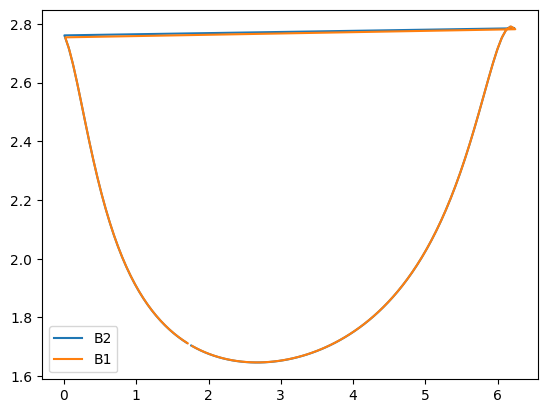

In [ ]:
plt.plot(B2_tv[0], B2_tv[1], label = "B2")
plt.plot(B1_tv[0], B1_tv[1], label = "B1")

plt.legend()


The difference is now visually unnoticeable. To properly compare them we first need to interpolate the points obtained.

In [7]:
from scipy.interpolate import CubicSpline
import numpy as np

def create_cubicspline(tv_arr):
    '''
    Computes the interpolated value v(t) 
    given an array of samples tv_arr.
    tv_arr[0] is the array of t values (increasing with one wrap-around jump).
    tv_arr[1] is the array of v values.
    The function is 2pi periodic.
    '''
    t_samples = tv_arr[0]
    v_samples = tv_arr[1]
    
    # Handle wrap-around: find the jump where t decreases
    # Find the index where t[i+1] < t[i]
    diffs = np.diff(t_samples)
    jump_indices = np.where(diffs < 0)[0]
    
    if len(jump_indices) > 0:
        # We take the first jump found
        idx = jump_indices[0] + 1
        # Reorder arrays to be strictly increasing in t
        t_sorted = np.concatenate([t_samples[idx:], t_samples[:idx]])
        v_sorted = np.concatenate([v_samples[idx:], v_samples[:idx]])
    else:
        # Already sorted or all values are same (unlikely)
        t_sorted = t_samples
        v_sorted = v_samples
        
    # Close the periodic loop to ensure CubicSpline(bc_type = 'periodic') works
    t_closed = np.concatenate([t_sorted, np.array([t_sorted[0] + 2*np.pi])])
    v_closed = np.concatenate([v_sorted, np.array([v_sorted[0]])])
    
    # Create the periodic cubic spline
    cs = CubicSpline(t_closed, v_closed, bc_type='periodic')
    
    return cs

In [8]:
t_vals = np.linspace(0, 2*np.pi, 2000)
cs1 = create_cubicspline(B1_tv)
cs2 = create_cubicspline(B2_tv)
B1_v_vals = np.array([cs1(t0) for t0 in t_vals])
B2_v_vals = np.array([cs2(t0) for t0 in t_vals])

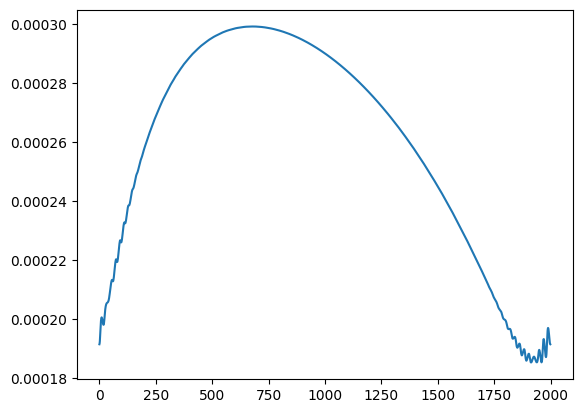

In [ ]:
plt.plot(np.arange(2000), B1_v_vals - B2_v_vals)

So we numerically confirm that the spread between both boundaries is below 1e-3. In fact it is on the order of 2e-4, at most 3e-4.

It seems intuitive that the difference associated to small wiggles will be that from the cubic spline. The main source of difference is still the difference coming from the real dv before backwards integration. Not sure, but these details are not crucial.

### We check the minimum escape time of points of B2

We try with 4 points equally spread: 0, np.pi/2, np.pi, np.pi*(3/2)

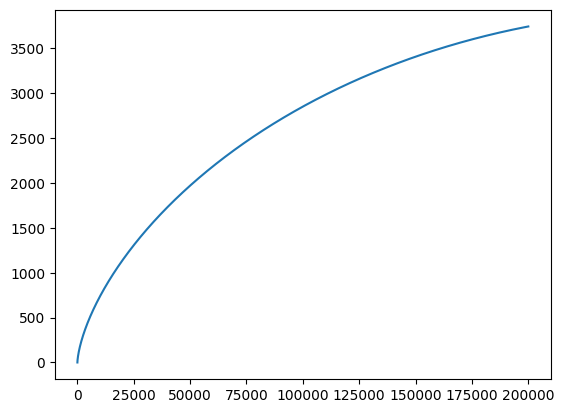

In [ ]:
t = 0
v = cs2(t)
from src.utils.plotting import plot_position_sitnikov
plot_position_sitnikov(T = 2e5, dt = 2, e=e, t=t, v=v)

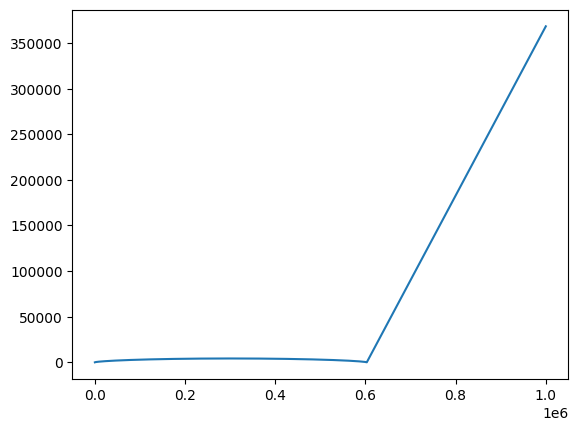

In [ ]:
t = np.pi/2
v = cs2(t)
from src.utils.plotting import plot_position_sitnikov
plot_position_sitnikov(T = 1e6, dt = 2, e=e, t=t, v=v)

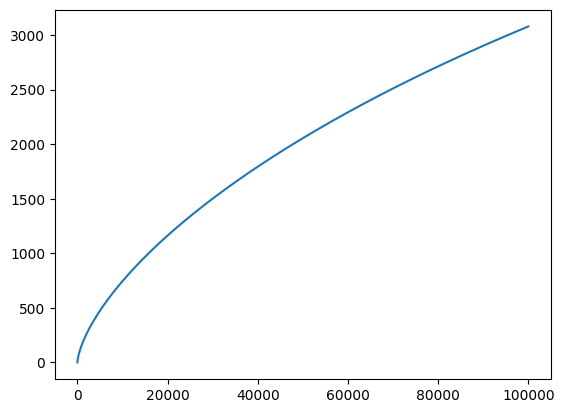

In [ ]:
t = np.pi
v = cs2(t)
from src.utils.plotting import plot_position_sitnikov
plot_position_sitnikov(T = 1e5, dt = 2, e=e, t=t, v=v)

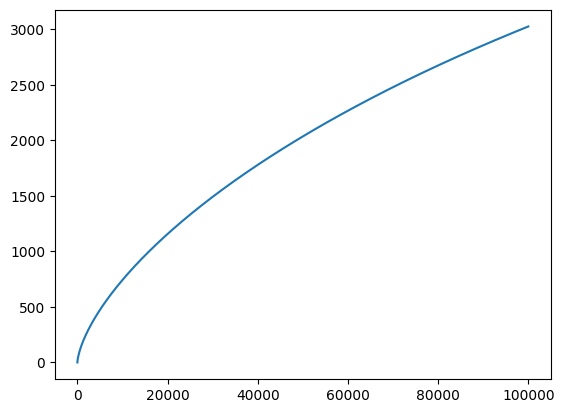

In [ ]:
t = 3*np.pi/2
v = cs2(t)
from src.utils.plotting import plot_position_sitnikov
plot_position_sitnikov(T = 1e5, dt = 2, e=e, t=t, v=v)

By having checked only 4 spread out values, it seems like the minimum return time is on the order of 1e5, and it is normally a factor larger. The only example of return found is for t = pi/2, T_ret = 6e5

#### Return time lower bound

Let's test how good the naive estimate of return time is, just computing the time to slow down from z = z0, v = v2 until v = 0 and falling back down in the extreme case of the primaries staying static at perihelion. Note numerical evidence shows that return time is dominated by the slow-down time. In this pa

In [9]:
def time_to_z0(e, t, v, z0_target):
    if v <= 0:
        return None
    
    sim = initialize_simulation(e=e, z=0, z_dot=v, t=t)
    
    # We want to find when z = z0_target. 
    # Since the particle is moving up from z=0 with v>0, 
    # it will reach z0_target.
    
    dt = 0.1
    t_start = sim.t
    
    # Integrate until we pass z0_target
    while sim.particles[2].z < z0_target:
        sim_prev = sim.copy()
        sim.integrate(sim.t + dt)
        
        # Safety break for escape or very long times (though reaching z0 should be fast)
        if sim.t - t_start > 10000: 
            return None

    # Refine with brentq to find exact crossing of z - z0_target = 0
    def z_target_func(tau):
        s = sim_prev.copy()
        s.integrate(tau)
        return s.particles[2].z - z0_target
    
    t_cross = brentq(z_target_func, sim_prev.t, sim.t, xtol=1e-14)
    return t_cross - t_start

# Compute z0 as in B2_tv_array for dv = 1e-3
dv_val = 1e-3
z0_target = (np.sqrt(2)/4 * e / dv_val)**(2/5)

# Same grid as before or use t_vals/N_t
N_samples = 20
t_grid = np.linspace(0, 2*np.pi, N_samples, endpoint=False)
z0_reach_times = []

for t0 in t_grid:
    v0 = cs2(t0)
    dt_z0 = time_to_z0(e, t0, v0, z0_target)
    if dt_z0 is not None:
        z0_reach_times.append(dt_z0)

# Print results
if z0_reach_times:
    print(f"Average time to reach z={z0_target:.4f}: {np.mean(z0_reach_times):.6f}")
    print(f"Min time to reach z={z0_target:.4f}: {np.min(z0_reach_times):.6f}")
    print(f"Max time to reach z={z0_target:.4f}: {np.max(z0_reach_times):.6f}")
else:
    print("No valid times computed.")

Average time to reach z=7.9245: 10.745685
Min time to reach z=7.9245: 10.659924
Max time to reach z=7.9245: 10.808150


## Lower bound for return

In [23]:
def return_time_lower_bound(e, z0, v0):
    '''
    Quick lower bound for return time.
    Assumes:
    z0, v0 > 0
    Return is guaranteed because 
    v <= v_esc(primaries at perihelion)  
    '''

    if z0 <= 0 or v0 <= 0:
        raise ValueError(f"Invalid input: expected z0 > 0 and v0 > 0, got z0={z0}, v0={v0}")
    
    a = 1/2 * (1-e)
    r0 = np.sqrt(z0**2 + a**2)

    if 1/2 * v0**2 - 1/r0 >= 0:
        raise ValueError(f"Invalid input: Return not guaranteed when setting primaries at perihelion, got z0 = {z0}, v0 = {v0}")
    
    rM = 1/ (1/r0 - 1/2 * v0**2 )
    u0 = r0/rM
    # Time to slow-down lower bound
    T = 1/np.sqrt(2) * rM**(3/2) * (np.pi/2 - np.arcsin(np.sqrt(u0)) + np.sqrt(u0)*np.sqrt(1-u0))

    return 2*T # going up and falling back down
    


In [24]:
z0 = (np.sqrt(2)/4 * e / dv_val)**(2/5)
r_2 = 1/2*(1+e)
v2 = np.sqrt(2/np.sqrt(z0**2 + r_2**2))
T = return_time_lower_bound(e,z0,v2)
print("Return time lower bound obtained is: {0:.3e}".format(T))

Return time lower bound obtained is: 1.995e+05
